In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from google import genai

from IPython.display import display
import textwrap
def wrap(text, width=100):
    print('\n'.join(textwrap.wrap(text, width)))
    
import yaml

from pydantic import BaseModel, Field

from typing import Literal
from openai import OpenAI

import statsmodels.api as sm
import statsmodels.formula.api as smf

import sys
import os

sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../..'))

from apa_style import set_apa_style, get_figsize, format_axes_labels
set_apa_style()

import re

def to_float(value_str):
    # This regex finds digits and periods only
    # It removes $, oz, commas, etc.
    clean_str = re.sub(r'[^\d.]', '', value_str)
    return float(clean_str)

def get_price_weight(choice = 'coffee_a'):
    cues = config['cues']
    cs = [c for c in cues if c['option_id']==choice]
    if not cs:
        return None, None
    
    weight = [c for c in cs if c['attribute_id']=='weight'][0]['value']
    weight = to_float(weight)
    list_price = [c for c in cs if c['attribute_id']=='list_price'][0]['value']
    list_price = to_float(list_price)
    discount_percentage = [c for c in cs if c['attribute_id']=='discount_percentage'][0]['value']
    discount_percentage = to_float(discount_percentage)
    sale_price = list_price - (list_price * discount_percentage/100)
    return sale_price, weight

def calculate_effective_value(row):
    # Base facts about the options (5 bags)
    choice = row['choice']
    if not choice:
        return 
    
    price, weight = get_price_weight(choice)

    bags = 5
    total_price = price * bags
    total_oz = weight * bags
    
    # Extract agent's path
    num_clicks = row['num_tool_calls']
    cost_per_click = row['inspect_cell_tool_cost']
    total_search_cost = num_clicks * cost_per_click
    
    total_spent = total_price + total_search_cost
        
    # The DV: Effective Cost per Gram
    effective_weight_dollar = total_oz / total_spent
    return effective_weight_dollar

def load_events(results_file: str | Path) -> pd.DataFrame:
    """Load events.jsonl file into a single DataFrame."""
    path = Path(results_file)
    if results_file.stem[0]=='_':
        return
    frames = []
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line]
    if rows:
        frames.append(pd.DataFrame(rows))
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    return df

def load_all_events(results_files: list) -> pd.DataFrame:
    all_dfs = []
    for rf in results_files:
        temp_df = load_events(rf)
        all_dfs.append(temp_df)
    return pd.concat(all_dfs, ignore_index=True)


def _load_analysis_config(config: dict[str, Any] | str | Path | None) -> dict[str, Any] | None:
    if config is None or isinstance(config, dict):
        return config
    path = Path(config)
    text = path.read_text(encoding="utf-8")
    if path.suffix.lower() == ".json":
        return json.loads(text)
    return yaml.safe_load(text)


def get_data():
    results_files = list(results_dir.glob('*-events.jsonl'))
    config_files = list(results_dir.glob('*-config.json'))
    config_file = config_files[0] if config_files else None
    config = _load_analysis_config(config_file)
    metadata_columns = list(config['metadata'].keys())
    # print('metadata_columns', metadata_columns)

    df_raw = load_all_events(results_files)
    df = df_raw.copy().sort_values(['session_name', 'step_index'])
    meta_df = df['meta'].dropna().apply(pd.Series)
    meta_df = meta_df.add_prefix('meta_')
    if not meta_df.empty:
        df = df.join(meta_df)

    meta_cols = df.filter(like='meta_').columns
    df[meta_cols] = df.groupby('session_name')[meta_cols].ffill()
    return df, config

exp_name = 'study4-promotion-final'

results_dir = Path('/home/dw/github/toollab/results/')/exp_name

df, config = get_data()
# print(f"{len(df)} events across {df['session_name'].nunique()} sessions")
# print(df[['option_count', 'design']])
print(df.columns)
print(df.shape)

all_attributes = [c['id'] for c in config['attributes']]

df = df.dropna(subset=['choice'])
df.groupby(['model_name', 'prompt_type','inspect_cell_tool_cost' ])['session_name'].nunique()

Index(['session_name', 'experiment_name', 'provider', 'model_name',
       'forced_choice', 'choice', 'budget_type', 'budget_max',
       'cumulative_cost_usd', 'budget_remaining_usd', 'cumulative_cost_tools',
       'budget_remaining_tools', 'cumulative_cost_tool_usd',
       'cumulative_cost_tokens', 'budget_remaining_tokens',
       'cumulative_cost_points', 'budget_remaining_points', 'option_count',
       'prompt_type', 'option_mapping', 'started_at', 'finished_at',
       'system_prompt', 'user_message', 'inspect_cell_tool_cost', 'step_index',
       'kind', 'content', 'reasoning', 'input_tokens', 'output_tokens',
       'input_cost', 'output_cost', 'tool_cost', 'point_cost', 'tool_usd_cost',
       'tool_calls', 'finish_reason', 'meta', 'tool_name', 'tool_call_id',
       'option_id', 'attribute_id', 'result', 'turn_cost_usd', 'is_revisit',
       'transition', 'confidence_score', 'most_important_attribute',
       'meta_thinking_level'],
      dtype='object')
(15734, 50)


model_name                     prompt_type     inspect_cell_tool_cost
gemini-3.1-flash-lite-preview  deal            0.0                       100
                                               10.0                      100
                               value_function  0.0                       100
                                               10.0                      100
gemini-3.1-pro-preview         deal            0.0                       100
                                               10.0                      100
                               value_function  0.0                       100
                                               10.0                      100
Name: session_name, dtype: int64

In [8]:
df, config = get_data()

def get_choice_discount(choice):
    if not choice:
        return np.nan
    cues = [c for c in config['cues'] if (c['option_id']==choice and c['attribute_id']=='discount_percentage')]
    if cues:
        return to_float(cues[0]['value'])
    else:
        # print(f'Choice: {choice} invalid')
        return np.nan 
    
df['choice_discount'] = df['choice'].apply(get_choice_discount)
df['choice_discounted'] = (df['choice_discount']!=0).astype(int)
df['is_optimal'] = df['choice'].apply(lambda choice: int(choice=='coffee_e') if choice else None)

df_session_list = []
for session_name, session in df.groupby('session_name'):
    # display((session))
    inspect_cell_tool_cost = session['inspect_cell_tool_cost'].iloc[0]
    prompt_type = session['prompt_type'].iloc[0]
    model_name = session['model_name'].iloc[0]
    choice = session['choice'].iloc[0]
    if choice=='coffee_c':
        choice_type = 'cheapest'
    elif choice=='coffee_d':
        choice_type = 'discounted'
    elif choice=='coffee_e':
        choice_type = 'optimal'

    choice_discount = session['choice_discount'].iloc[0]
    choice_discounted = session['choice_discounted'].iloc[0]
    is_optimal = session['is_optimal'].iloc[0]

    subset_choice = session[session['tool_name']=='submit_choice']
    if subset_choice.empty:
        most_important_attribute = None    
    else:
        most_important_attribute = subset_choice['most_important_attribute'].iloc[0]

    # print(session.columns)
    subset_tools = session[session['tool_name']=='inspect_cell']
    # display(subset_tools.columns)
    tools_called = subset_tools['attribute_id'].unique().tolist()
    # print('tools_called', tools_called)
    num_tool_calls = len(subset_tools)

    # --- Tool / Search Info ---
    subset_tools = session[session['tool_name'] == 'inspect_cell']
    
    # 1. Overall volume of search
    num_tool_calls = len(subset_tools)
    total_tool_cost_usd = session['cumulative_cost_tool_usd'].max() # Total money spent on tools
    
    # 2. Breadth of search (Options)
    options_inspected = subset_tools['option_id'].dropna().unique().tolist()
    option_mapping = session['option_mapping'].iloc[0]
    options_inspected = [option_mapping[opt] for opt in options_inspected]
    # print(option_mapping)
    # print(options_inspected)

    num_options_inspected = len(options_inspected)
    
    # 3. Depth of search (Attributes)
    tools_called = subset_tools['attribute_id'].dropna().unique().tolist()
    
    # Specific attribute checks (Did they do the math or use a heuristic?)
    called_discount = int(any('discount' in str(tool) for tool in tools_called))
    called_weight = int('weight' in tools_called)
    called_list_price = int('list_price' in tools_called)
    
    # Exhaustive math proxy: Did they check the 3 components needed to calculate true value?
    has_math_components = int(called_discount and called_weight and called_list_price)

    # 4. Sequence / Stopping Rule (What triggered the choice?)
    if not subset_tools.empty:
        last_attribute_inspected = subset_tools['attribute_id'].iloc[-1]
        last_option_inspected = subset_tools['option_id'].iloc[-1]
        last_option_inspected = option_mapping[last_option_inspected]
        # print(f"last option: {subset_tools['option_id'].iloc[-1]}")
        # print(option_mapping)

        # Did they choose the item they were looking at right before stopping?
        chose_last_inspected = int(last_option_inspected == choice) 
    else:
        last_attribute_inspected = None
        last_option_inspected = None
        chose_last_inspected = 0
        
    # 5. Search efficiency
    num_revisits = subset_tools['is_revisit'].sum() if 'is_revisit' in subset_tools.columns else 0

    df_session_list.append({
        'session_name': session_name,
        'inspect_cell_tool_cost': inspect_cell_tool_cost,
        'prompt_type': prompt_type,
        'model_name': model_name,
        
        # Choice details
        'choice': choice,
        'choice_type':choice_type,
        'choice_discount': choice_discount,
        'choice_discounted': choice_discounted,
        'is_optimal': is_optimal,
        'most_important_attribute': most_important_attribute,
        
        # Search Truncation & Efficiency metrics
        'num_tool_calls': num_tool_calls,
        'total_tool_cost_usd': total_tool_cost_usd,
        'num_options_inspected': num_options_inspected,
        'num_revisits': num_revisits,
        
        # Heuristic vs Calculation metrics
        'tools_called': tools_called,
        'called_discount': called_discount, 
        'called_weight': called_weight,
        'called_list_price': called_list_price,
        'has_math_components': has_math_components,
        
        # Mouselab Sequence/Stopping variables
        'last_attribute_inspected': last_attribute_inspected,
        'last_option_inspected': last_option_inspected,
        'chose_last_inspected': chose_last_inspected
    })
    
df_session = pd.DataFrame(df_session_list)
df_session['Effective_Oz_Per_Dollar'] = df_session.apply(calculate_effective_value, axis=1)

# # cap to 100 per cell
# df_session = df_session.groupby(
#     ['model_name', 'prompt_type', 'inspect_cell_tool_cost']
# ).head(100)
df_session.groupby(['model_name', 'prompt_type','inspect_cell_tool_cost'])['session_name'].nunique()


model_name                     prompt_type     inspect_cell_tool_cost
gemini-3.1-flash-lite-preview  deal            0.0                       100
                                               10.0                      100
                               value_function  0.0                       100
                                               10.0                      100
gemini-3.1-pro-preview         deal            0.0                       100
                                               10.0                      100
                               value_function  0.0                       100
                                               10.0                      100
Name: session_name, dtype: int64

In [ ]:
df_session.groupby(['prompt_type','model_name', 'inspect_cell_tool_cost'])['choice_type'].value_counts(normalize=True)


prompt_type     model_name                     inspect_cell_tool_cost  choice_type
deal            gemini-3.1-flash-lite-preview  0.0                     discounted     0.85
                                                                       cheapest       0.10
                                                                       optimal        0.05
                                               10.0                    discounted     0.85
                                                                       cheapest       0.11
                                                                       optimal        0.04
                gemini-3.1-pro-preview         0.0                     optimal        0.84
                                                                       cheapest       0.09
                                                                       discounted     0.07
                                               10.0                    optimal        0.65
       

In [5]:
df_session.groupby(['model_name', 'inspect_cell_tool_cost'])['num_tool_calls'].mean()


model_name                     inspect_cell_tool_cost
gemini-3.1-flash-lite-preview  0.0                       9.000
                               10.0                      8.755
gemini-3.1-pro-preview         0.0                       9.185
                               10.0                      8.395
Name: num_tool_calls, dtype: float64

### Descriptive stats/plots

In [3]:
df_session.columns

Index(['session_name', 'inspect_cell_tool_cost', 'prompt_type', 'model_name',
       'choice', 'choice_type', 'choice_discount', 'choice_discounted',
       'is_optimal', 'most_important_attribute', 'num_tool_calls',
       'total_tool_cost_usd', 'num_options_inspected', 'num_revisits',
       'tools_called', 'called_discount', 'called_weight', 'called_list_price',
       'has_math_components', 'last_attribute_inspected',
       'last_option_inspected', 'chose_last_inspected',
       'Effective_Oz_Per_Dollar'],
      dtype='object')

In [6]:
import pandas as pd

# Grouping variables representing our experimental design
group_vars = ['prompt_type', 'model_name', 'inspect_cell_tool_cost']

# 1. Choice Distribution (Percentages of Coffee C, D, and E)
# Unstacking creates a nice table with C, D, E as columns
choice_dist = df_session.groupby(group_vars)['choice'].value_counts(normalize=True).unstack(fill_value=0) * 100
oz_per_dollar_dist = df_session.groupby(group_vars)['Effective_Oz_Per_Dollar'].mean()

print("=== 1. CHOICE DISTRIBUTION (%) ===")
print(choice_dist.round(1))
print("=== 1. Total Weight per Total Cost (%) ===")

print(oz_per_dollar_dist.round(3))

=== 1. CHOICE DISTRIBUTION (%) ===
choice                                                               coffee_c  \
prompt_type    model_name                    inspect_cell_tool_cost             
deal           gemini-3.1-flash-lite-preview 0.0                         10.0   
                                             10.0                        11.0   
               gemini-3.1-pro-preview        0.0                          9.0   
                                             10.0                        34.0   
value_function gemini-3.1-flash-lite-preview 0.0                          2.0   
                                             10.0                         1.0   
               gemini-3.1-pro-preview        0.0                          0.0   
                                             10.0                         0.0   

choice                                                               coffee_d  \
prompt_type    model_name                    inspect_cell_tool_cost      

([0, 1], [Text(0, 0, '0.0'), Text(1, 0, '10.0')])

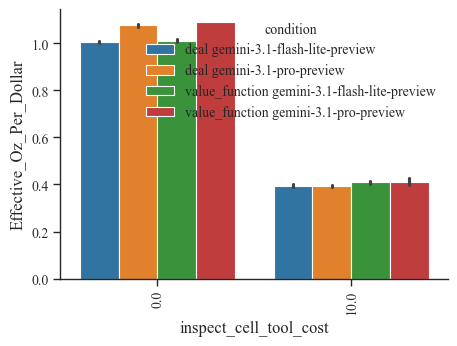

In [24]:
df_session['condition'] = df_session['prompt_type'] + ' ' + df_session['model_name']
sns.barplot(
    df_session,
    x = 'inspect_cell_tool_cost',
    y = 'Effective_Oz_Per_Dollar',
    hue = 'condition',
    palette='tab10'
)
plt.xticks(rotation=90)

(0.3, 0.45039192089160834)

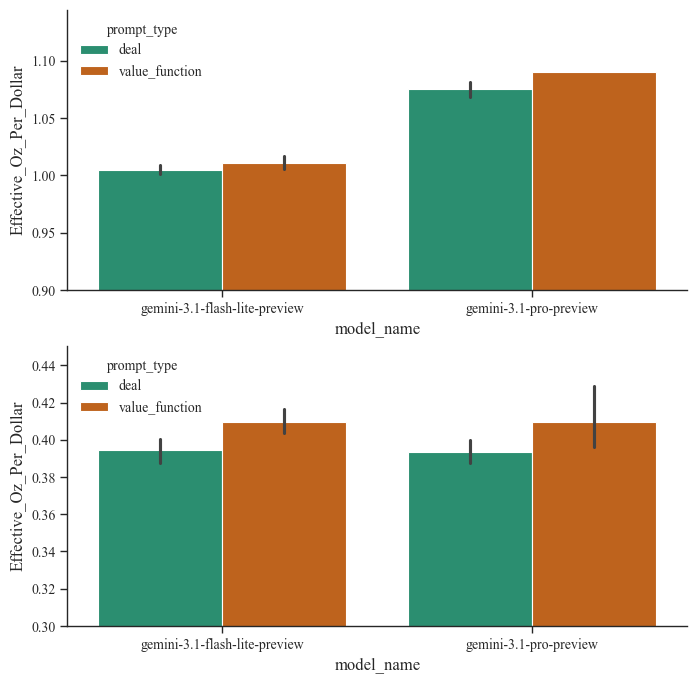

In [50]:
fig, axes = plt.subplots(2,1, figsize=(8,8))
for i, cost in enumerate(df_session['inspect_cell_tool_cost'].unique()):
    sns.barplot(
        df_session[df_session['inspect_cell_tool_cost']==cost],
        x = 'model_name',
        y = 'Effective_Oz_Per_Dollar',
        hue = 'prompt_type',
        palette='Dark2',
        ax=axes[i]
    )

axes[0].set_ylim(0.9)
axes[1].set_ylim(0.3)

In [37]:
df_session.groupby(['prompt_type','inspect_cell_tool_cost','model_name'])['num_tool_calls'].mean()


prompt_type     inspect_cell_tool_cost  model_name                   
deal            0.0                     gemini-3.1-flash-lite-preview    9.00
                                        gemini-3.1-pro-preview           9.37
                10.0                    gemini-3.1-flash-lite-preview    8.84
                                        gemini-3.1-pro-preview           8.03
value_function  0.0                     gemini-3.1-flash-lite-preview    9.00
                                        gemini-3.1-pro-preview           9.00
                10.0                    gemini-3.1-flash-lite-preview    8.67
                                        gemini-3.1-pro-preview           8.76
Name: num_tool_calls, dtype: float64

In [35]:
df_session.groupby(['inspect_cell_tool_cost','model_name'])['Effective_Oz_Per_Dollar'].mean()

inspect_cell_tool_cost  model_name                   
0.0                     gemini-3.1-flash-lite-preview    1.007650
                        gemini-3.1-pro-preview           1.082800
10.0                    gemini-3.1-flash-lite-preview    0.402054
                        gemini-3.1-pro-preview           0.401393
Name: Effective_Oz_Per_Dollar, dtype: float64

In [17]:

# 2. Search Depth and Information Acquisition Stats
search_stats = df_session.groupby(group_vars).agg(
    Mean_Tool_Calls=('num_tool_calls', 'mean'),
    SD_Tool_Calls=('num_tool_calls', 'std'),
    # Multiplying by 100 to get percentages
    Checked_Triad_Pct=('has_math_components', lambda x: x.mean() * 100), 
    Optimal_Choice_Pct=('is_optimal', lambda x: x.mean() * 100)
).reset_index()

print("=== 2. SEARCH DEPTH & INFORMATION ACQUISITION ===")
print(search_stats.round(1))


=== 2. SEARCH DEPTH & INFORMATION ACQUISITION ===
      prompt_type                     model_name  inspect_cell_tool_cost  \
0            deal  gemini-3.1-flash-lite-preview                     0.0   
1            deal  gemini-3.1-flash-lite-preview                    10.0   
2            deal         gemini-3.1-pro-preview                     0.0   
3            deal         gemini-3.1-pro-preview                    10.0   
4  value_function  gemini-3.1-flash-lite-preview                     0.0   
5  value_function  gemini-3.1-flash-lite-preview                    10.0   
6  value_function         gemini-3.1-pro-preview                     0.0   
7  value_function         gemini-3.1-pro-preview                    10.0   

   Mean_Tool_Calls  SD_Tool_Calls  Checked_Triad_Pct  Optimal_Choice_Pct  
0              9.0            0.0              100.0                 5.0  
1              8.8            0.6               98.0                 4.0  
2              9.4            1.5       

### Stat modelling

In [18]:
df_session_deal = df_session[df_session['prompt_type']=='deal']
df_session_deal.prompt_type.value_counts()

deal    400
Name: prompt_type, dtype: int64

### has_math_components

In [23]:
# has_math_components

print("--- TEST 1: LOGISTIC REGRESSION ON has_math_components ---")
formula_1 = "has_math_components ~ C(model_name, Treatment('gemini-3.1-flash-lite-preview')) * inspect_cell_tool_cost"

try:
    logit_model = smf.logit(formula=formula_1, data=df_session_deal).fit(disp=False)
    print(logit_model.summary())
    
except Exception as e:
    print(f"Error fitting Logit Model: {e}")

--- TEST 1: LOGISTIC REGRESSION ON has_math_components ---
                            Logit Regression Results                           
Dep. Variable:     has_math_components   No. Observations:                  400
Model:                           Logit   Df Residuals:                      396
Method:                            MLE   Df Model:                            3
Date:                 Thu, 23 Apr 2026   Pseudo R-squ.:                  0.3643
Time:                         08:15:18   Log-Likelihood:                -70.890
converged:                       False   LL-Null:                       -111.51
Covariance Type:             nonrobust   LLR p-value:                 1.668e-17
                                                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### num_tool_calls

In [28]:
# num_tool_calls

print("--- TEST 1: OLS REGRESSION ON TOTAL TOOL CALLS ---")
formula_2 = "num_tool_calls ~ C(model_name, Treatment('gemini-3.1-flash-lite-preview')) * inspect_cell_tool_cost"

try:
    # We use Poisson because num_tool_calls is a count variable (0, 1, 2, 3...)
    ols_model = smf.ols(formula=formula_2, data=df_session_deal).fit(disp=False)
    print(ols_model.summary())
    
except Exception as e:
    print(f"Error fitting OLS Model: {e}")

--- TEST 1: OLS REGRESSION ON TOTAL TOOL CALLS ---
                            OLS Regression Results                            
Dep. Variable:         num_tool_calls   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     26.28
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.60e-15
Time:                        08:23:51   Log-Likelihood:                -604.73
No. Observations:                 400   AIC:                             1217.
Df Residuals:                     396   BIC:                             1233.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                                                                                 coef    std err          t      P>|t|      [0.

#### is_optimal

In [21]:
# is_optimal
formula_1 = "is_optimal ~ C(model_name, Treatment('gemini-3.1-flash-lite-preview')) * inspect_cell_tool_cost"

try:
    logit_overall = smf.logit(formula=formula_1, data=df_session_deal).fit(disp=False)
    print(logit_overall.summary())
except Exception as e:
    logit_model = smf.logit(formula=formula_1, data=df_session_deal)
    results_reg = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False)
    print('REGULARIZED: ',results_reg.summary())
    print(f"Error fitting Model 1: {e}")

                           Logit Regression Results                           
Dep. Variable:             is_optimal   No. Observations:                  400
Model:                          Logit   Df Residuals:                      396
Method:                           MLE   Df Model:                            3
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.4584
Time:                        08:05:10   Log-Likelihood:                -145.36
converged:                       True   LL-Null:                       -268.37
Covariance Type:            nonrobust   LLR p-value:                 4.724e-53
                                                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept         

In [9]:
df_session_deal.groupby(['model_name', 'inspect_cell_tool_cost'])['is_optimal'].mean()


model_name                     inspect_cell_tool_cost
gemini-3.1-flash-lite-preview  0.0                       0.05
                               10.0                      0.04
gemini-3.1-pro-preview         0.0                       0.84
                               10.0                      0.65
Name: is_optimal, dtype: float64

<Axes: xlabel='inspect_cell_tool_cost', ylabel='is_optimal'>

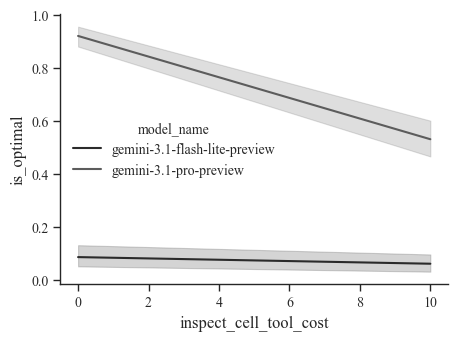

In [10]:
df_session_deal.groupby(['model_name', 'inspect_cell_tool_cost'])['choice_type'].value_counts(normalize=True)
sns.lineplot(
    df_session,
    x = 'inspect_cell_tool_cost',
    y = 'is_optimal',
    hue='model_name'
)

#### Multinomial Choice

In [21]:
df_session_copy = df_session.copy()

In [22]:
# 1. Map strings to integers explicitly. 
# 0 = optimal (this becomes the baseline reference)
# 1 = cheapest
# 2 = discounted
mapping = {'optimal': 0, 'cheapest': 1, 'discounted': 2}
df_session_copy['choice_type_int'] = df_session_copy['choice_type'].str.strip().map(mapping)

# 2. Update formula to use the new integer column
formula_s4_3 = "choice_type_int ~ C(model_name, Treatment('gemini-3.1-flash-lite-preview')) * inspect_cell_tool_cost"

try:
    # 3. Fit the model
    # We use method='bfgs' as it handles small sample/pilot data slightly better
    mnlogit_model = smf.mnlogit(formula=formula_s4_3, data=df_session_copy).fit(disp=False, method='bfgs')
    print("--- MULTINOMIAL LOGIT RESULTS ---")
    print(mnlogit_model.summary())
    
except Exception as e:
    print(f"Error fitting mnlogit: {e}")
    print("\nWarning: The solver failed. This confirms 'Perfect Separation'.")
    print("Because Flash Lite chose 'optimal' ZERO times, the math cannot compute the variance.")

--- MULTINOMIAL LOGIT RESULTS ---
                          MNLogit Regression Results                          
Dep. Variable:        choice_type_int   No. Observations:                   80
Model:                        MNLogit   Df Residuals:                       72
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4271
Time:                        14:14:22   Log-Likelihood:                -38.104
converged:                      False   LL-Null:                       -66.512
Covariance Type:            nonrobust   LLR p-value:                 1.991e-10
                                                                                         choice_type_int=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------------

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Choice type binary logit

In [28]:
import statsmodels.formula.api as smf

# 1. Create binary Yes/No flags for the specific heuristic choices
df_session_copy['chose_cheapest'] = (df_session_copy['choice_type'].str.strip() == 'cheapest').astype(int)
df_session_copy['chose_discounted'] = (df_session_copy['choice_type'].str.strip() == 'discounted').astype(int)

# --- TEST A: Does the Large Model fall back to the "Cheapest" Heuristic? ---
print("\n--- TEST A: BINARY LOGIT (Probability of Choosing 'Cheapest') ---")
formula_cheapest = "chose_cheapest ~ C(model_name, Treatment('gemini-3.1-flash-lite-preview')) * inspect_cell_tool_cost"
try:
    logit_cheapest = smf.logit(formula_cheapest, data=df_session_copy).fit(disp=False)
    print(logit_cheapest.summary())
except Exception as e:
    print(f"Error in Test A: {e}")

# --- TEST B: Is the Small Model blinded by the "Discount" Cue? ---
print("\n--- TEST B: BINARY LOGIT (Probability of Choosing 'Discounted') ---")
formula_discounted = "chose_discounted ~ C(model_name, Treatment('gemini-3.1-flash-lite-preview')) * inspect_cell_tool_cost"
try:
    logit_discount = smf.logit(formula_discounted, data=df_session_copy).fit(disp=False)
    print(logit_discount.summary())
except Exception as e:
    print(f"Error in Test B: {e}")



--- TEST A: BINARY LOGIT (Probability of Choosing 'Cheapest') ---
                           Logit Regression Results                           
Dep. Variable:         chose_cheapest   No. Observations:                   80
Model:                          Logit   Df Residuals:                       76
Method:                           MLE   Df Model:                            3
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1998
Time:                        14:17:39   Log-Likelihood:                -24.121
converged:                      False   LL-Null:                       -30.142
Covariance Type:            nonrobust   LLR p-value:                  0.007242
                                                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### called_discount

In [17]:
# Expectation: At cost=$10, the Pro model's probability of calling the 'discount_percentage' tool drops to near zero, proving it intentionally ignored the discount cue to save money.
formula_s4_4 = "called_discount ~ C(model_name) * inspect_cell_tool_cost"

try:
    logit_overall = smf.logit(formula=formula_s4_4, data=df_session).fit(disp=False)
    print(logit_overall.summary())
except Exception as e:
    logit_model = smf.logit(formula=formula_s4_4, data=df_session)
    results_reg = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False)
    print('REGULARIZED: ',results_reg.summary())
    print(f"Error fitting Model 1: {e}")

                           Logit Regression Results                           
Dep. Variable:        called_discount   No. Observations:                   80
Model:                          Logit   Df Residuals:                       76
Method:                           MLE   Df Model:                            3
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3953
Time:                        14:10:20   Log-Likelihood:                -3.2508
converged:                      False   LL-Null:                       -5.3758
Covariance Type:            nonrobust   LLR p-value:                    0.2357
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------
Intercept                                                         29.0825   2.92e+05   9.95e-05      1.000

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Prompt type

In [48]:
# Expectation: At cost=$10, the Pro model's probability of calling the 'discount_percentage' tool drops to near zero, proving it intentionally ignored the discount cue to save money.
formula_prompt_2 = "is_optimal ~ "
formula_prompt_2 += '''C(prompt_type, Treatment('deal')) * C(model_name, Treatment('gemini-3.1-flash-lite-preview'))'''
formula_prompt_2 += '''+ C(prompt_type, Treatment('deal')) * inspect_cell_tool_cost '''
# formula_prompt_2 += ''' + C(prompt_type, Treatment('deal')) * C(model_name, Treatment('gemini-3.1-flash-lite-preview')) '''

try:
    logit_prompt = smf.logit(formula=formula_prompt_2, data=df_session).fit(disp=False)
    print(logit_prompt.summary())
except Exception as e:
    print(f"Error: {e}")


                           Logit Regression Results                           
Dep. Variable:             is_optimal   No. Observations:                  800
Model:                          Logit   Df Residuals:                      794
Method:                           MLE   Df Model:                            5
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.4520
Time:                        09:00:58   Log-Likelihood:                -294.81
converged:                       True   LL-Null:                       -538.00
Covariance Type:            nonrobust   LLR p-value:                6.964e-103
                                                                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------

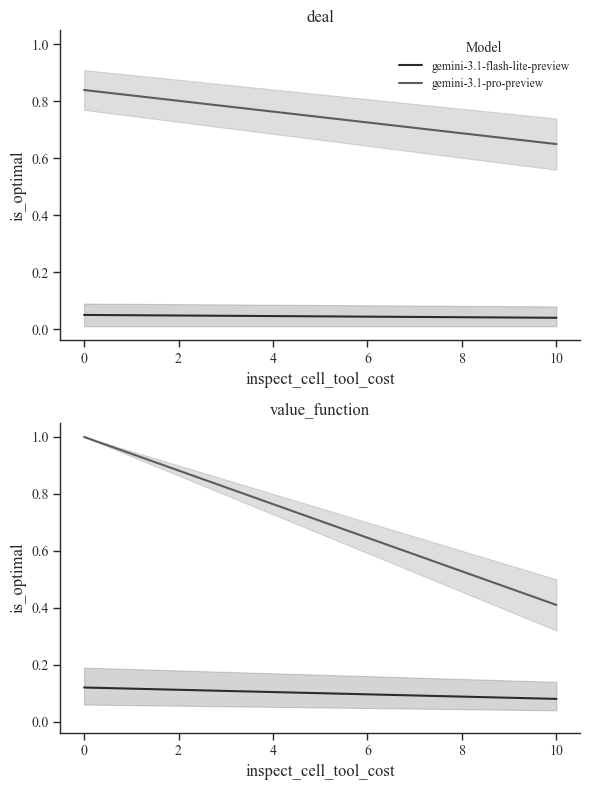

In [49]:
fig, axes = plt.subplots(2, 1, sharey=True, figsize=(6, 8))
for ax, (prompt_type, subset) in zip(axes, df_session.groupby('prompt_type')):
    sns.lineplot(data=subset, y='is_optimal', x='inspect_cell_tool_cost', hue='model_name', ax=ax)
    ax.set_title(prompt_type)
    # 'best' automatically finds the emptiest corner
    ax.legend(title='Model', loc='best', fontsize='small') 
axes[1].get_legend().remove()
fig.tight_layout()
fig.savefig('figures/prompt_type_optimal.png', dpi=300)

### Most important attributes

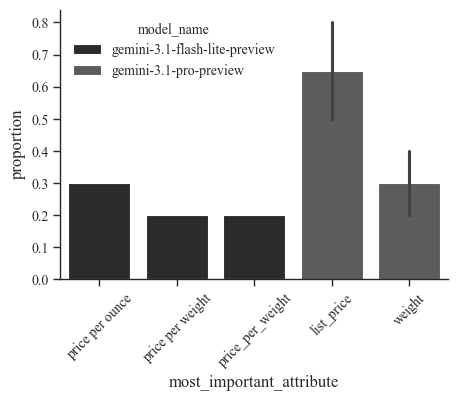

In [54]:
most_important_attribute_counts = df_session.groupby(['model_name', 'inspect_cell_tool_cost'])['most_important_attribute'].value_counts(normalize=True)

most_important_attribute_counts = most_important_attribute_counts[most_important_attribute_counts>0.1]
most_important_attribute_counts
ax = sns.barplot(
    most_important_attribute_counts.reset_index(name='proportion'),
    y = 'proportion',
    x = 'most_important_attribute',
    hue='model_name'
)
ax.tick_params(axis='x', rotation=45)

# the effect of constraint on choice

#### Resource rational analysis

In [30]:
# 1. Load the autoreload extension
%load_ext autoreload

# 2. Set it to automatically reload all modules before running code
%autoreload 2

# 3. Import your updated classes
from mdp_mcts.mcts import Attribute, ToolPlanner

# costs_to_test = [0.0, 1, 5, 10.0]
costs_to_test = np.linspace(0,10,11)
n_simulations = 1 # How many random shops to simulate per cost
products = ["coffee_c", "coffee_d", 'coffee_e'] # Update if you have more products
optimal_records = []

print("Simulating Optimal Policy...")
for cost in costs_to_test:
    # 1. Set up the environment with the current cost
    attributes_discount = [
        Attribute(
            name="dollars",
            domain=np.arange(1, 100),
            cost=cost,
        ),
        Attribute(
            name="weight",
            domain=np.arange(1, 100),
            cost=cost,
        ),
        Attribute(
            name="discount_percentage",
            domain=np.arange(0, 70, 5),
            cost=cost,
        ),
    ]
    
    planner = ToolPlanner(
        products=products, 
        attributes=attributes_discount, 
        num_bags=5,

        algorithm="mcts",            
        mcts_iterations=500_000, 

        tie_break_reveal_penalty=1e-6
    )
    
    # 2. Run simulations
    for sim_id in range(n_simulations):
        # # Generate a random true state of the world
        # realization = {}
        # for p in products:
        #     for a in attributes_discount:
        #         realization[(p, a.name)] = float(np.random.choice(a.domain))
        realization_discount = {
            ("coffee_c", "dollars"): 8,
            ("coffee_c", "weight"): 8,
            ("coffee_c", "discount_percentage"): 0,

            ("coffee_d", "dollars"): 15,
            ("coffee_d", "weight"): 12,
            ("coffee_d", "discount_percentage"): 20,

            # ("A", "cents"): 91,
            ("coffee_e", "dollars"): 10,
            ("coffee_e", "weight"): 10.9,
            ("coffee_e", "discount_percentage"): 0,
            # ("B", "cents"): 90,
        }
        state = planner.initial_state()
        num_reveals = 0
        
        # Step through the MDP
        while True:
            plan = planner.plan(state)
            action = plan["best_action"]
            
            if action[0] == "choose":
                break # Agent stopped searching
                
            # Agent decided to reveal, update state
            state, _ = planner.apply_real_observation(state, realization_discount, plan["stats"][0]["raw_action"] if "raw_action" in plan["stats"][0] else action)
            num_reveals += 1
        print('inspect_cell_tool_cost', cost, 'num_tool_calls', num_reveals)
        optimal_records.append({
            'inspect_cell_tool_cost': cost,
            'num_tool_calls': num_reveals,
            'model_name': 'Optimal Policy' # This acts as our baseline "model"
        })

print("Simulation Complete!")
df_optimal = pd.DataFrame(optimal_records)
df_optimal


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Simulating Optimal Policy...
inspect_cell_tool_cost 0.0 num_tool_calls 9
inspect_cell_tool_cost 1.0 num_tool_calls 6
inspect_cell_tool_cost 2.0 num_tool_calls 5
inspect_cell_tool_cost 3.0 num_tool_calls 6
inspect_cell_tool_cost 4.0 num_tool_calls 6
inspect_cell_tool_cost 5.0 num_tool_calls 4
inspect_cell_tool_cost 6.0 num_tool_calls 4
inspect_cell_tool_cost 7.0 num_tool_calls 4
inspect_cell_tool_cost 8.0 num_tool_calls 4
inspect_cell_tool_cost 9.0 num_tool_calls 4
inspect_cell_tool_cost 10.0 num_tool_calls 4
Simulation Complete!


,inspect_cell_tool_cost,num_tool_calls,model_name
0,0.0,9,Optimal Policy
1,1.0,6,Optimal Policy
2,2.0,5,Optimal Policy
3,3.0,6,Optimal Policy
4,4.0,6,Optimal Policy
5,5.0,4,Optimal Policy
6,6.0,4,Optimal Policy
7,7.0,4,Optimal Policy
8,8.0,4,Optimal Policy
9,9.0,4,Optimal Policy


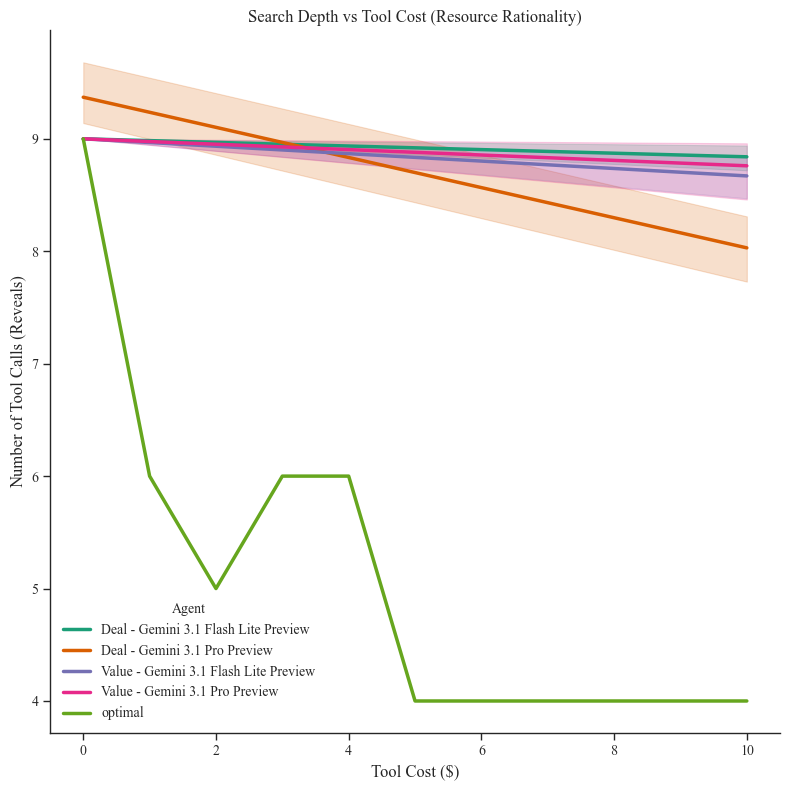

In [31]:
# df_session_deal = df_session[df_session['prompt_type']=='deal']
# df_session_value = df_session[df_session['prompt_type']=='value_function']
df_session_condition = df_session.copy()
df_session_condition['condition'] = df_session_condition['prompt_type'].str.replace('_function','').str.title() + ' - ' + df_session_condition['model_name'].str.replace('-',' ').str.title()
df_optimal['condition'] = 'optimal'
df_combined = pd.concat([df_session_condition, df_optimal], ignore_index=True)
df_combined['log_num_tool_calls'] = np.log10(df_combined['num_tool_calls']+1)
df_combined['log_inspect_cell_tool_cost'] = np.log10(df_combined['inspect_cell_tool_cost']+1)

# Plotting
plt.figure(figsize=(8, 8))

# Create a custom color palette so the Optimal line stands out (e.g., black)
conditions = df_combined['condition'].unique()
# palette = {condition: "black" if condition == "optimal" else sns.color_palette("Dark2")[i] 
#            for i, condition in enumerate(conditions)}


# Add a dashed line style specifically for the Optimal Policy
dashes = {condition: (1, 1) if condition == "optimal" else "" for condition in conditions}

sns.lineplot(
    data=df_combined,
    x='inspect_cell_tool_cost',
    y='num_tool_calls',
    hue='condition',
    # style='condition', # Allows custom line styles
    palette='Dark2',
    # dashes=dashes,
    markers=True,
    linewidth=2.5
)

plt.title("Search Depth vs Tool Cost (Resource Rationality)")
plt.xlabel("Tool Cost ($)")
plt.ylabel("Number of Tool Calls (Reveals)")
plt.legend(title="Agent")
plt.tight_layout()
plt.show()


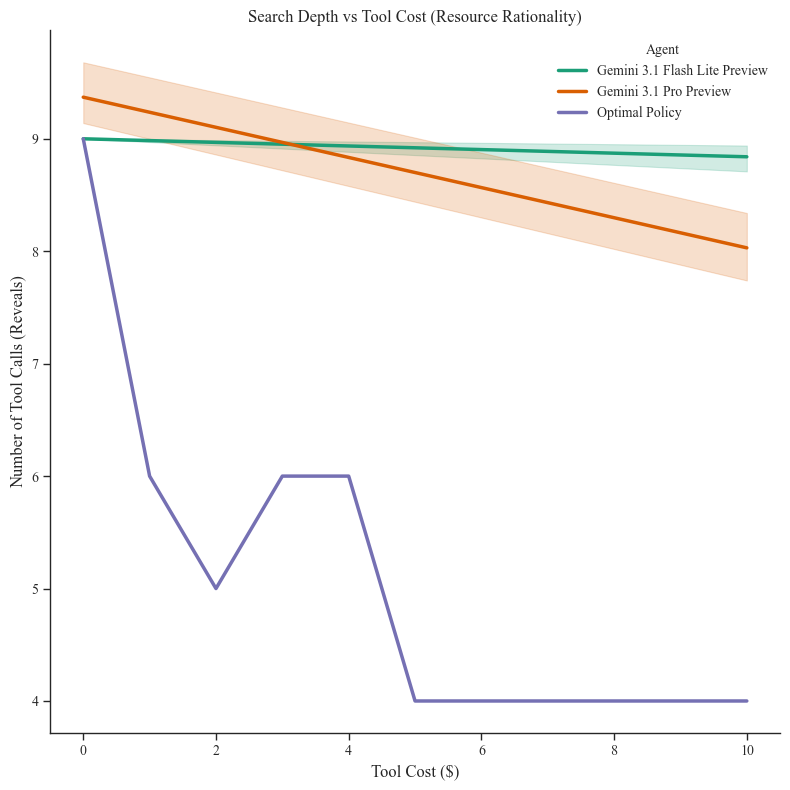

In [32]:
df_session_deal = df_session[df_session['prompt_type']=='deal']
df_session_condition = df_session_deal.copy()
df_session_condition['model_name'] = df_session_condition['model_name'].str.replace('-',' ').str.title()
df_combined = pd.concat([df_session_condition, df_optimal], ignore_index=True)
df_combined['log_num_tool_calls'] = np.log10(df_combined['num_tool_calls']+1)
df_combined['log_inspect_cell_tool_cost'] = np.log10(df_combined['inspect_cell_tool_cost']+1)

# Plotting
plt.figure(figsize=(8, 8))

# Create a custom color palette so the Optimal line stands out (e.g., black)
conditions = df_combined['condition'].unique()

# Add a dashed line style specifically for the Optimal Policy
dashes = {condition: (1, 1) if condition == "optimal" else "" for condition in conditions}

sns.lineplot(
    data=df_combined,
    x='inspect_cell_tool_cost',
    y='num_tool_calls',
    hue='model_name',
    # style='condition', # Allows custom line styles
    palette='Dark2',
    # dashes=dashes,
    # markers=True,
    linewidth=2.5
)

plt.title("Search Depth vs Tool Cost (Resource Rationality)")
plt.xlabel("Tool Cost ($)")
plt.ylabel("Number of Tool Calls (Reveals)")
plt.legend(title="Agent")
plt.tight_layout()
plt.show()


In [34]:
def ci_95(x):
    # Standard error * 1.96 (for 95% confidence)
    return 1.96 * x.sem()
print(df_combined.groupby(['inspect_cell_tool_cost', 'model_name'])['num_tool_calls'].agg(['mean', ci_95]).reset_index())

    inspect_cell_tool_cost                     model_name  mean     ci_95
0                      0.0  Gemini 3.1 Flash Lite Preview  9.00  0.000000
1                      0.0         Gemini 3.1 Pro Preview  9.37  0.284993
2                      0.0                 Optimal Policy  9.00       NaN
3                      1.0                 Optimal Policy  6.00       NaN
4                      2.0                 Optimal Policy  5.00       NaN
5                      3.0                 Optimal Policy  6.00       NaN
6                      4.0                 Optimal Policy  6.00       NaN
7                      5.0                 Optimal Policy  4.00       NaN
8                      6.0                 Optimal Policy  4.00       NaN
9                      7.0                 Optimal Policy  4.00       NaN
10                     8.0                 Optimal Policy  4.00       NaN
11                     9.0                 Optimal Policy  4.00       NaN
12                    10.0  Gemini 3.1

<Axes: xlabel='inspect_cell_tool_cost', ylabel='Effective_Oz_Per_Dollar'>

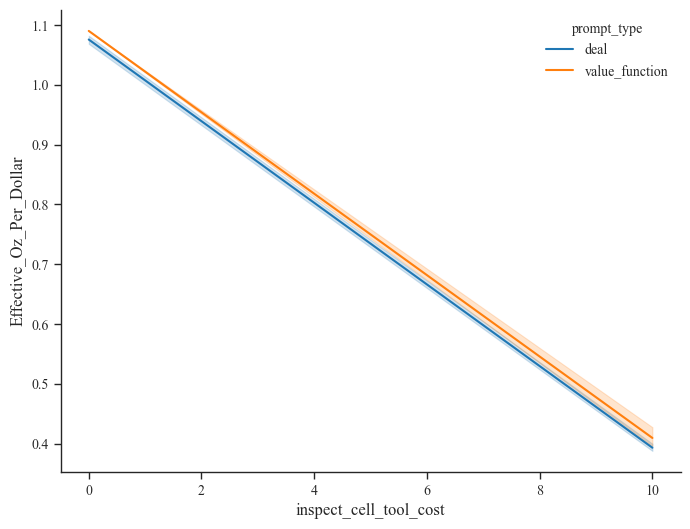

In [25]:
plt.figure(figsize=(8, 6))

df_session_condition_pro = df_session_condition[df_session_condition['model_name']=='gemini-3.1-pro-preview']

sns.lineplot(
    df_session_condition_pro,
    y = 'Effective_Oz_Per_Dollar',
    x = 'inspect_cell_tool_cost',
    hue='prompt_type',
    palette='tab10'
)

In [3]:
# df, config = get_data()

# inspect_cell_tool_cost = 10.0
# gemini_pro = df[(df['model_name']=='gemini-3.1-pro-preview') & (df['inspect_cell_tool_cost']==inspect_cell_tool_cost) & (df['prompt_type']=='value_function')]
# reasoning_traces = []
# for index, (session_name, subset) in enumerate(gemini_pro.groupby('session_name')):
#     print(index, session_name, subset['inspect_cell_tool_cost'].max())
#     if (index+1)<len(gemini_pro.groupby('session_name')): continue
#     assistant = subset[subset['kind']=='assistant']
#     reasoning_trace_list = []
#     for step, (i, row) in enumerate(assistant.iterrows(), 1):
#         print(i)
#         reasoning = row['reasoning']
#         tc = subset.loc[i+1,['attribute_id', 'result', 'tool_name', 'cumulative_cost_tool_usd']]
#         wrap(reasoning)
#         reasoning_trace_list.append(f"Reasoning Step {step}:\n{reasoning.strip()}")
#         reasoning_trace_list.append('-'*50)
#         if tc['tool_name']=='inspect_cell':
#             display(tc)
#             reasoning_trace_list.append(f"Tool Response Step {step}:\n{tc.to_string().strip()}")
#             reasoning_trace_list.append('-'*50)

#         else:
#             print()
#             print(f"Choice: {row['choice']}, most_important_attribute: {subset.loc[i+1, 'most_important_attribute']}")
#             reasoning_trace_list.append(f"Choice: {row['choice']}")

#         # break
#     full_trace = '\n\n'.join(reasoning_trace_list)
#     reasoning_traces.append({
#         'session_name': session_name,
#         'full_trace': full_trace,
#     })
#     # display(assistant)
#     # break
#     print('+'*50)

3.25

2.5

2.5688073394495414

### Moderated mediation

In [ ]:
from pyprocessmacro import Process

# Prepare the data (ensure continuous/dummy formats)
df_process = df_session.dropna(subset=['model_name', 'inspect_cell_tool_cost', 'num_tool_calls']).copy()

df_process = df_process[df_process['prompt_type']=='deal']
# df_session.choice_type.unique()
df_process.prompt_type.unique()

array(['deal'], dtype=object)

In [30]:


df_process['chose_suboptimal'] = (df_process['choice_type'] != 'optimal').astype(int)
df_process['chose_optimal'] = (df_process['choice_type'] == 'optimal').astype(int)

df_process['X_Model_Pro'] = (df_process['model_name'].str.contains('pro')).astype(int) # 1 if Pro, 0 if Flash
df_process['W_Cost'] = df_process['inspect_cell_tool_cost']
df_process['M_Search_Depth'] = df_process['num_tool_calls']
df_process['Y_Choice_Optimal'] = df_process['chose_optimal']

# Run PROCESS Model 7
p = Process(data=df_process, 
            model=7, 
            x='X_Model_Pro', 
            y='Y_Choice_Optimal', 
            m=['M_Search_Depth'], 
            w='W_Cost', 
            logit=True,   # Because Y (chose_cheapest) is binary
            boot=10_000,
            seed=12345)

p.summary()


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 7

Variables:
    Cons = Cons
    x = X_Model_Pro
    y = Y_Choice_Optimal
    m1 = M_Search_Depth
    w = W_Cost

Sample size:
400

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 10000
Number of samples discarded due to convergence issues: 162

***************************** OUTCOME MODELS ****************************


**************************************************************************
Outcome = Y_Choice_Optimal 
Logistic Regression Summary

     -2LL  Model LL  p-value  McFadden  Cox-Snell  Nagelkerke    n
 247.3700  289.3757   0.0000    0.5391     0.5149      0.6971  400

Coefficients

                  coeff     se       Z      p     LLCI    ULCI
Cons           -11.8239 1.5225 -7.7661 0.0000 -14.8079 -8.8398
X_Model_Pro      4.6346 0.4004 11.5761 0.0000

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which

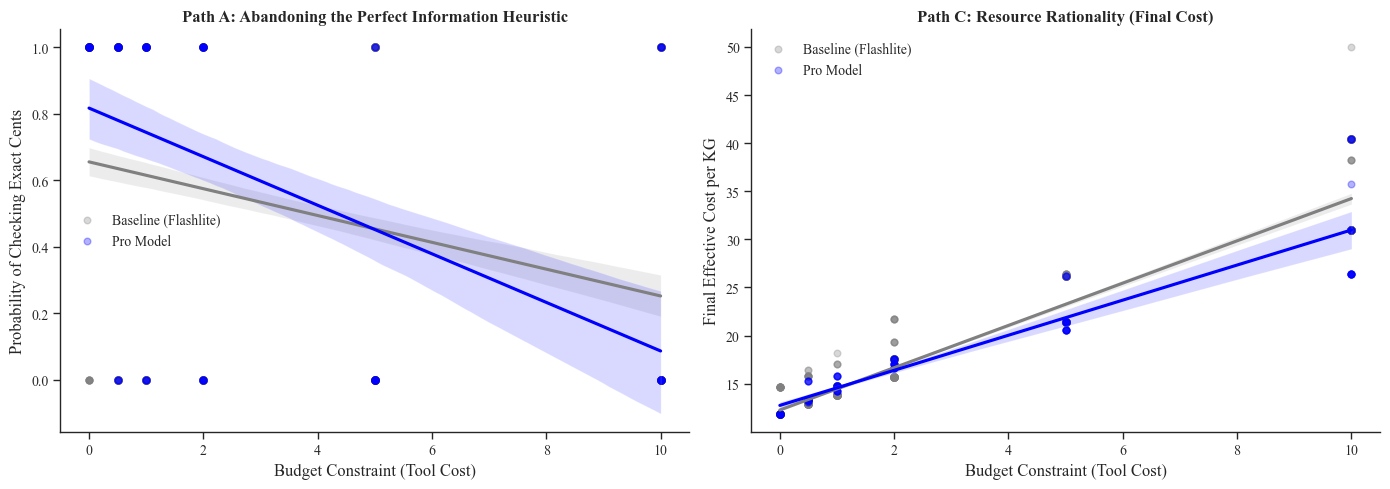

In [20]:
# Set academic style (clean, white background, no distracting grids)
# sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Create a figure with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: The Heuristic (Checking Cents)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 0], 
    x='inspect_cell_tool_cost', y='checked_cents', 
    ax=axes[0], color='gray', label='Baseline (Flashlite)', scatter_kws={'alpha':0.3}
)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 1], 
    x='inspect_cell_tool_cost', y='checked_cents', 
    ax=axes[0], color='blue', label='Pro Model', scatter_kws={'alpha':0.3}
)
axes[0].set_title('Path A: Abandoning the Perfect Information Heuristic', fontweight='bold')
axes[0].set_xlabel('Budget Constraint (Tool Cost)')
axes[0].set_ylabel('Probability of Checking Exact Cents')
axes[0].legend()

# Plot B: The Final Outcome (Effective Cost)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 0], 
    x='inspect_cell_tool_cost', y='Effective_Cost_Per_KG', 
    ax=axes[1], color='gray', label='Baseline (Flashlite)', scatter_kws={'alpha':0.3}
)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 1], 
    x='inspect_cell_tool_cost', y='Effective_Cost_Per_KG', 
    ax=axes[1], color='blue', label='Pro Model', scatter_kws={'alpha':0.3}
)
axes[1].set_title('Path C: Resource Rationality (Final Cost)', fontweight='bold')
axes[1].set_xlabel('Budget Constraint (Tool Cost)')
axes[1].set_ylabel('Final Effective Cost per KG')
axes[1].legend()

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()


## Stat modelling

In [76]:
import statsmodels.formula.api as smf

model_name_to_size_dict = {
    'gemini-3.1-flash-lite-preview':'small',        
    'gemini-3-flash-preview':'medium',
    'gemini-3.1-pro-preview':'large',
}


In [77]:
# # 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
# search_proportions = pd.crosstab(
#     df['budget_max'], 
#     df['attribute_id'], 
#     normalize='index' # Converts counts to percentages (0.0 to 1.0)
# )

# # 2. Plot as a Stacked Bar Chart
# search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

# plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
# plt.xlabel('Max Budget (budget_max)', fontsize=12)
# plt.ylabel('Number of Total Searches', fontsize=12)
# plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

## Classify trace reasoning

In [139]:
from tool_lab.models.llamacpp_adapter import LlamaCppClient
class Config:
    model_name = 'gemma-4-31B-it-UD-Q4_K_XL.gguf'

attribute_list = [att['id'] for att in config['attributes']]

class AttributeClassification(BaseModel):
    label: Literal[*attribute_list]

def classify_choice_attribute(reasoning_text: str) -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    attribute_string = ''
    for att in attribute_list:
        attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are a highly precise data annotator analyzing the decision-making process of AI models. "
        "You will be provided with the reasoning an AI model gave for choosing a specific product. "
        "Your task is to identify the primary attribute that determined the model's final choice.\n\n"
        "Classify the reasoning into exactly one of these categories:\n"
        f'{attribute_string}'
    )
    
    user_prompt = reasoning_text

    try:
        response = client.chat.completions.parse(
            model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=AttributeClassification,
        )
        
        # Extract and clean up the classification result
        # print(response.choices[0])
        category = response.choices[0].message.parsed
        return category.label
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"


class TraceExtraction(BaseModel):
    # 1. Cost & Search Logic
    mentioned_tool_cost: bool = Field(
        description="Did the agent explicitly mention the numerical cost of using a tool (e.g., $2.00) in the text?"
    )
    performed_voi_calculation: bool = Field(
        description="Did the agent explicitly weigh the cost of searching against the potential monetary savings? (e.g., 'Checking this costs $3 but could save me $10')"
    )
    explicitly_skipped_cents: bool = Field(
        description="Did the agent explicitly state a reason for NOT checking the cents? (e.g., 'Cents won't make enough of a difference')."
    )

    # 2. Imputation of Missing Data (The Left-Digit Bias Check)
    cents_imputation_strategy: Literal["assumed_zero", "assumed_average", "acknowledged_missing_but_ignored", "not_mentioned"] = Field(
        description="How did the agent handle the missing cents when doing math? 'assumed_zero' means they treated the price as exactly $12.00 or $13.00. 'assumed_average' means they added ~0.50. 'acknowledged_missing' means they said 'we don't know the cents' but didn't assign a number."
    )

    # 3. Mathematical Evaluation
    calculated_value_ratio: bool = Field(
        description="Did the agent attempt to calculate a ratio of Price-to-Weight or Weight-to-Price? (e.g., '$0.92 per ounce' or '1.08 oz per dollar')"
    )
    math_hallucination: bool = Field(
        description="Based on the numbers the agent explicitly wrote down, was their final arithmetic incorrect?"
    )

    # 4. Tie-Breaking & Decision Rule
    primary_stated_decision_rule: Literal["best_value_ratio", "lowest_absolute_price", "highest_total_weight", "other"] = Field(
        description="What was the final stated reason for choosing the winning coffee?"
    )
    confidence_in_text: Literal["high", "moderate", "low"] = Field(
        description="Assess the tone of the final choice. 'high' means definitive ('clearly option A is better'). 'low' means uncertain ('I guess A might be better')."
    )


def classify_reasoning_trace(reasoning_text: str, provider='google') -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    # attribute_string = ''
    # for att in attribute_list:
    #     attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are an expert qualitative researcher analyzing the internal 'scratchpad' reasoning traces of an AI agent participating in an economic shopping simulation.\n"
        "The agent was choosing between Option A (approx $12, 13oz) and Option B (approx $13, 14.06oz) while paying to reveal hidden attributes.\n"
        "Read the provided reasoning trace carefully.\n" 
        "Your job is to extract the specific psychological and algorithmic behaviors the agent exhibited, strictly according to the provided JSON schema.\n"
        "Do not infer traits that are not explicitly written in the text or clearly demonstrated in the agent's written math."
    )
    
    try:
        if provider=='llamacpp':
            LlamaCppClient(Config())

            client = OpenAI(
                base_url='http://localhost:8080/v1',
                api_key="sk-no-key-required"
            )
            response = client.chat.completions.parse(
                model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": reasoning_text}
                ],
                response_format=TraceExtraction,
            )
            
            # Extract and clean up the classification result
            # print(response.choices[0])
            result = response.choices[0].message.parsed
        elif provider=='google':
            client = genai.Client()
            response = client.models.generate_content(
                model="gemini-3.1-flash-lite-preview",
                contents=reasoning_text,
                config={
                    "response_mime_type": "application/json",
                    "response_json_schema": TraceExtraction.model_json_schema(),
                    "system_instruction":system_prompt
                },
            )
            result = TraceExtraction.model_validate_json(response.text)

        return result
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"

In [127]:
trace_extraction = classify_reasoning_trace(reasoning_text=reasoning_traces[0])
trace_extraction

TraceExtraction(mentioned_tool_cost=True, performed_voi_calculation=True, explicitly_skipped_cents=False, cents_imputation_strategy='assumed_zero', calculated_value_ratio=True, math_hallucination=False, primary_stated_decision_rule='lowest_absolute_price', confidence_in_text='high')

In [142]:
for i, trace in enumerate(reasoning_traces):
    trace_extraction = classify_reasoning_trace(reasoning_text=trace['full_trace'])
    trace_extraction_dict = dict(trace_extraction)
    trace.update(trace_extraction_dict)
    # reasoning_traces[i] = dict(**trace, **trace_extraction_dict)


In [145]:
reasoning_traces

[{'session_name': '20260417T144433839636Z',
  'full_trace': 'Reasoning Step 1:\n**Coffee Purchase Decision**\n\nOkay, so I need to get ten bags of coffee. I have two options, let\'s call them option\\_1 and option\\_2. The problem is I don\'t have all the details at my fingertips. I *could* use `inspect_cell` to dig deeper, but each call costs fifty cents, which quickly adds up. I need to make a smart decision here. I need to figure out which option is going to give me the best deal on the beans.\n\nPrice is definitely key here. Since there\'s no stated preference, the price per bag is going to be my primary driver. I\'m thinking I\'ll need to look at `price_dollars` and `price_cents` for each option. The weight, `weight_oz`, will also matter as this would allow me to calculate price per ounce. Perhaps other attributes like `origin`, `brand`, or the `roast_date` might be relevant later, but, for now, I\'m focusing on the bottom line. So, let\'s start by checking those `price_dollars` a

# Rest

In [157]:
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'most_important_attribute':'first',
    'model_name': 'first'
})
most_important_attribute

,most_important_attribute,model_name
session_name,,
20260415T161414407849Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161429371264Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161443870482Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161520966406Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161604519148Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
...,...,...
20260415T232900107105Z,discount_percentage,gemini-3-flash-preview
20260415T232908851853Z,discount_percentage,gemini-3-flash-preview
20260416T011818303367Z,discount_percentage,gemini-3.1-pro-preview


In [158]:
reasoning_df = df[df['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

# 2. Your existing aggregation
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
sample = submit_choice_reasoning.iloc[0]
submit_choice_reasoning

,model_name,budget_max,most_important_attribute,reasoning
session_name,,,,
20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...
20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...
20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
...,...,...,...,...
20260415T232900107105Z,gemini-3-flash-preview,1,discount_percentage,**Decision Time: Limited Information and Budge...
20260415T232908851853Z,gemini-3-flash-preview,1,discount_percentage,"**My Decision: Option 1**\n\nOkay, here's the ..."
20260416T011818303367Z,gemini-3.1-pro-preview,20,discount_percentage,"**My Decision-Making Process**\n\nOkay, so I'm..."


In [159]:
submit_choice_reasoning.isna().sum()

model_name                  0
budget_max                  0
most_important_attribute    0
reasoning                   2
dtype: int64

In [ ]:
# submit_choice_reasoning['predicted_attribute'] = None
for i, row in submit_choice_reasoning.iterrows():
    predicted_attribute = classify_choice_attribute(row['reasoning'])
    submit_choice_reasoning.at[i, 'predicted_attribute'] = predicted_attribute
    print(row['model_name'], row['budget_max'], predicted_attribute, 'vs.', row['most_important_attribute'])

In [61]:
# submit_choice_reasoning.to_csv(results_dir/'predicted_attributes.csv')


In [93]:
submit_choice_reasoning = pd.read_csv(results_dir/'predicted_attributes.csv')
submit_choice_reasoning

,session_name,model_name,budget_max,most_important_attribute,reasoning,predicted_attribute
0,20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...,weight_oz
1,20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
2,20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...,discount_percentage
3,20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
4,20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
...,...,...,...,...,...,...
235,20260415T211739771084Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,discount_percentage,Option_3 is not discounted. So if we're lookin...,discount_percentage
236,20260415T211835575838Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,Both option_1 and option_3 were roasted 2 week...,weight_oz
237,20260415T211933959232Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option_2 has only 3 left in stock, but it's st...",weight_oz
238,20260415T212023423393Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option 1: $12.60 (no discount), 11.5 oz\nPrice...",weight_oz


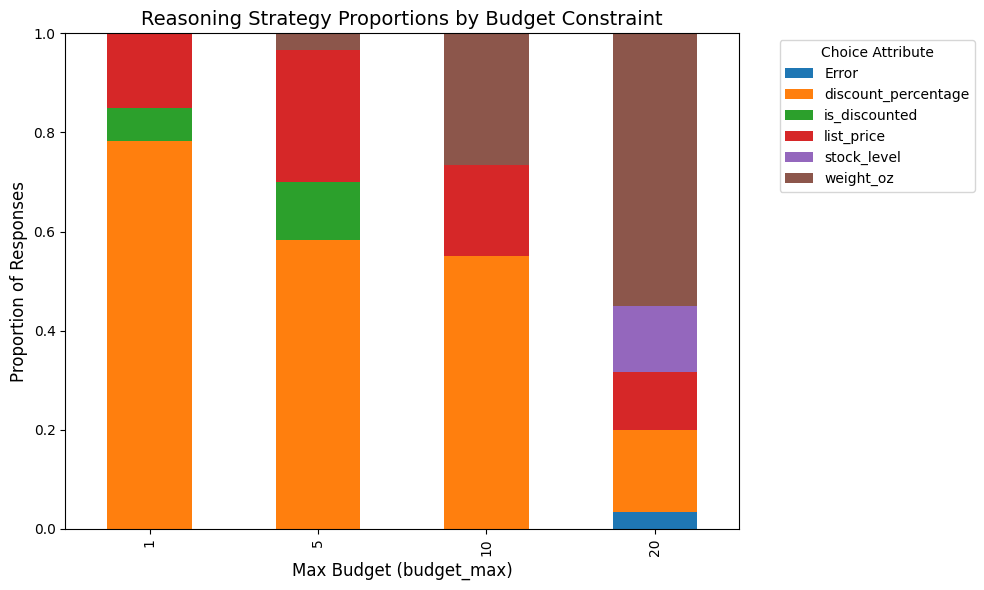

In [76]:
# 1. Create a cross-tabulation and normalize it so each row sums to 1.0 (100%)
crosstab_pred = pd.crosstab(
    submit_choice_reasoning['budget_max'], 
    submit_choice_reasoning['predicted_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_pred.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

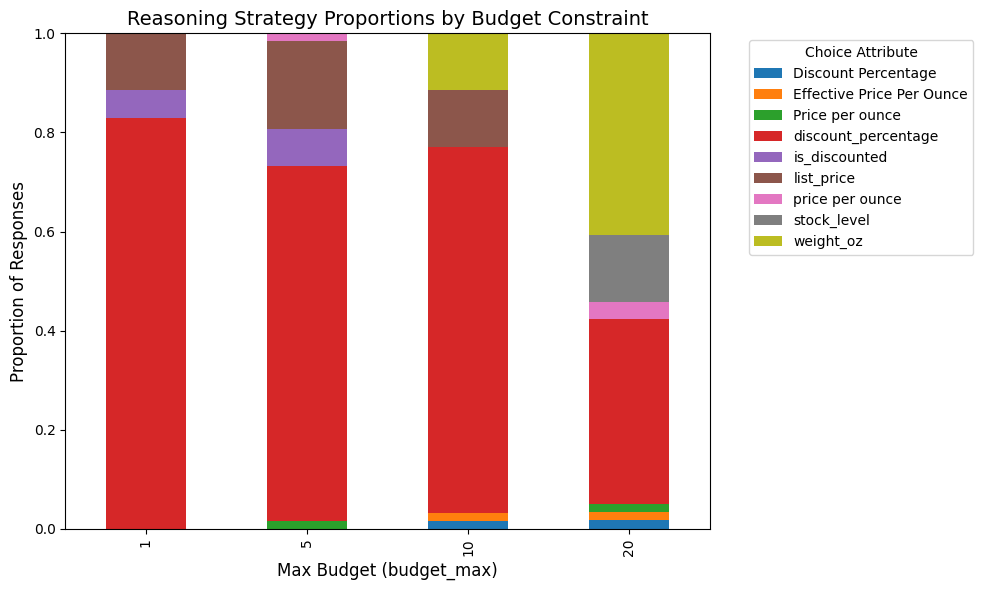

In [144]:
claimed_counts = submit_choice_reasoning['most_important_attribute'].value_counts()
top_claims = claimed_counts[claimed_counts>1].index
top_claims_df = submit_choice_reasoning[submit_choice_reasoning['most_important_attribute'].isin(top_claims)]
top_claims_df['most_important_attribute'].value_counts()

crosstab_claimed = pd.crosstab(
    top_claims_df['budget_max'], 
    top_claims_df['most_important_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_claimed.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [102]:
submit_choice_reasoning['model_name'].unique()

<StringArray>
['gemma-4-31B-it-UD-Q4_K_XL.gguf',    'Qwen3.5-27B-UD-Q4_K_XL.gguf',
     'Qwen3.5-9B-UD-Q4_K_XL.gguf',     'Qwen3.5-4B-UD-Q4_K_XL.gguf',
 'gemma-4-E4B-it-UD-Q4_K_XL.gguf', 'gemma-4-E2B-it-UD-Q4_K_XL.gguf']
Length: 6, dtype: str

In [109]:
# submit_choice_reasoning['num_params']
model_name_to_billion_dict = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 31,    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 27,
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 9,     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 4,
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 4, 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 2,
}
model_name_to_family = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 'gemma',    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 'qwen',
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 'qwen',     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 'qwen',
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 'gemma', 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 'gemma',
}


In [115]:
import statsmodels.formula.api as smf

# Convert the boolean column to integer (0 or 1) for the model
submit_choice_reasoning['discount_target'] = (submit_choice_reasoning['predicted_attribute']=='discount_percentage').astype(int)
submit_choice_reasoning['num_params'] = submit_choice_reasoning['model_name'].map(model_name_to_billion_dict)
submit_choice_reasoning['model_family'] = submit_choice_reasoning['model_name'].map(model_name_to_family)

# Fit the logistic regression model
# This tests if continuous 'budget_max' predicts the binary 'discount_target'
logit_model = smf.logit('discount_target ~ budget_max + num_params * model_family', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.589494
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        discount_target   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1485
Time:                        15:50:16   Log-Likelihood:                -141.48
converged:                       True   LL-Null:                       -166.15
Covariance Type:            nonrobust   LLR p-value:                 4.967e-10
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           1.2876      0.335      3.844  

### Attributes checked

In [105]:
df, config = get_data(exp_name)
df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

model_name                      budget_max
Qwen3.5-27B-UD-Q4_K_XL.gguf     1             10
                                4             10
                                6             10
                                16            10
Qwen3.5-4B-UD-Q4_K_XL.gguf      1             10
                                4             10
                                6             10
                                16            10
Qwen3.5-9B-UD-Q4_K_XL.gguf      1             10
                                4             10
                                6             10
                                16            10
gemini-3-flash-preview          1             10
                                4             10
                                6             10
                                16            10
gemini-3.1-flash-lite-preview   1             10
                                4             10
                                6             10
                          

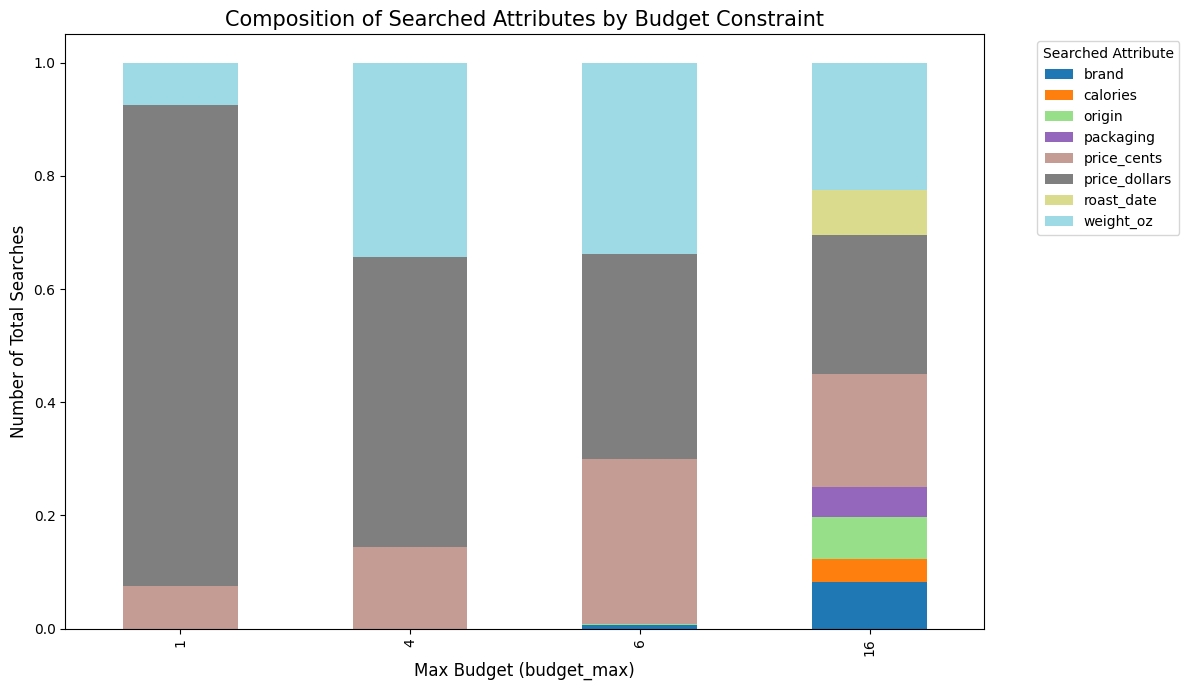

In [106]:
# 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
search_proportions = pd.crosstab(
    df['budget_max'], 
    df['attribute_id'], 
    normalize='index' # Converts counts to percentages (0.0 to 1.0)
)

# 2. Plot as a Stacked Bar Chart
search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Number of Total Searches', fontsize=12)
plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

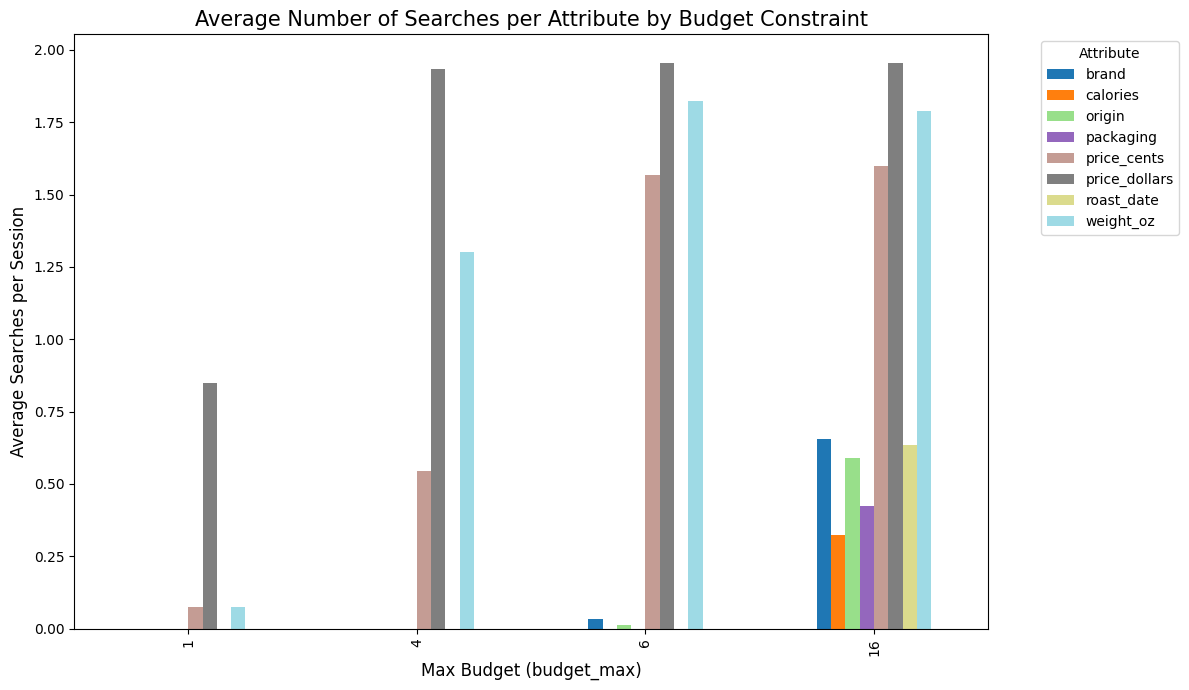

In [107]:
df_summary = (
    df.groupby(['session_name', 'budget_max'])['attribute_id']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
# 1. Using the df_summary from the previous step:
# Drop 'session_name' so we only have numbers, then group by budget and get the mean
mean_searches_per_budget = df_summary.drop(columns=['session_name']).groupby('budget_max').mean()
mean_searches_per_budget

# 2. Plot as a grouped bar chart (not stacked)
mean_searches_per_budget.plot(kind='bar', figsize=(12, 7), colormap='tab20')

plt.title('Average Number of Searches per Attribute by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Average Searches per Session', fontsize=12)
plt.legend(title='Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### most_important_attribute

In [108]:
df, config = get_data(exp_name)
# (df[df['budget_max']==20]).groupby('model_name')['choice'].value_counts(dropna=False)
if df.choice.isna().sum():
    print(f'we have missing choices: {df.choice.isna().sum()}')
# df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

we have missing choices: 4


In [109]:
df_submit_choice = (df[(df['kind']=='tool')&(df['tool_name']=='submit_choice')]).copy()
df_submit_choice_summary = (
    df_submit_choice.groupby(['budget_max'])['most_important_attribute']
    .value_counts(normalize=True)
    # .unstack(fill_value=0)
    .reset_index()
)

([0, 1, 2, 3],
 [Text(0, 0, '1'), Text(1, 0, '4'), Text(2, 0, '6'), Text(3, 0, '16')])

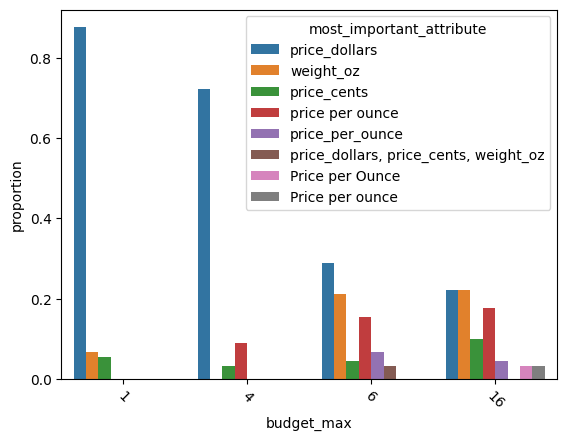

In [110]:
df_summary_count_g1 = df_submit_choice_summary[df_submit_choice_summary['proportion']>0.03]
ax = sns.barplot(data = df_summary_count_g1, hue = 'most_important_attribute', y = 'proportion', x='budget_max')
plt.xticks(rotation=-45)

In [ ]:
df_copy = df.copy()
df_copy['is_inspect'] = df_copy['tool_name'] == 'inspect_cell'


reasoning_df = df_copy[df_copy['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

num_inspect = df_copy.groupby(['session_name']).agg({
    'is_inspect': 'sum',
}).rename({'is_inspect':'num_inspect'}, axis=1)
num_inspect['num_inspect'].value_counts()

# 2. Your existing aggregation
most_important_attribute = (df_copy[df_copy['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
    'choice':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
submit_choice_reasoning = submit_choice_reasoning.join(num_inspect)

price_stats = df_copy.groupby('session_name')['attribute_id'].agg(
    has_price_cents = lambda x: (x == 'price_cents').any().astype(int),
    count_price_cents = lambda x: (x == 'price_cents').sum()
)

# 2. Join to your existing summary dataframe
submit_choice_reasoning = submit_choice_reasoning.join(price_stats)

total_attributes = 8
num_options = 2
total_cells = total_attributes * num_options
submit_choice_reasoning['constraint'] = 1 - (submit_choice_reasoning['budget_max']/total_cells)
TOTAL_PRICE_CENTS = 2
submit_choice_reasoning['ignored_price_cents'] = TOTAL_PRICE_CENTS - submit_choice_reasoning['count_price_cents']

submit_choice_reasoning['ignored_cents_bool'] = 1 - submit_choice_reasoning['has_price_cents']

submit_choice_reasoning['oz_per_price'] = submit_choice_reasoning['choice'].apply(lambda choice: [opt['base_score'] for opt in config['options'] if opt['id']==choice][0])


# submit_choice_reasoning.groupby(['model_name','budget_max']).count()
# submit_choice_reasoning

In [115]:
import statsmodels.formula.api as smf

# Fit the logistic regression model
logit_model = smf.ols('ignored_price_cents ~ constraint', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

                             OLS Regression Results                            
Dep. Variable:     ignored_price_cents   R-squared:                       0.285
Model:                             OLS   Adj. R-squared:                  0.283
Method:                  Least Squares   F-statistic:                     142.3
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):           7.78e-28
Time:                         11:09:22   Log-Likelihood:                -441.99
No. Observations:                  359   AIC:                             888.0
Df Residuals:                      357   BIC:                             895.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1974      0.084      2.34

(0.9, 1.1224499999999997)

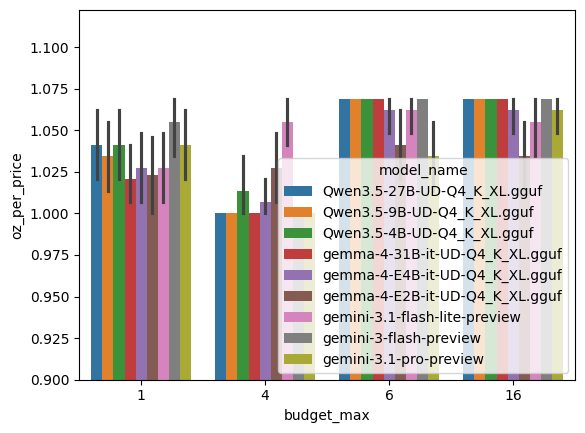

In [140]:
sns.barplot(submit_choice_reasoning, x = 'budget_max', y = 'oz_per_price', hue='model_name')
plt.ylim(0.9)

In [144]:
submit_choice_reasoning.groupby(['budget_max', 'model_name'])['choice'].value_counts()

budget_max  model_name                      choice  
1           Qwen3.5-27B-UD-Q4_K_XL.gguf     coffee_b     6
                                            coffee_a     4
            Qwen3.5-4B-UD-Q4_K_XL.gguf      coffee_b     6
                                            coffee_a     4
            Qwen3.5-9B-UD-Q4_K_XL.gguf      coffee_a     5
                                            coffee_b     5
            gemini-3-flash-preview          coffee_b     8
                                            coffee_a     2
            gemini-3.1-flash-lite-preview   coffee_a     6
                                            coffee_b     4
            gemini-3.1-pro-preview          coffee_b     6
                                            coffee_a     4
            gemma-4-31B-it-UD-Q4_K_XL.gguf  coffee_a     7
                                            coffee_b     3
            gemma-4-E2B-it-UD-Q4_K_XL.gguf  coffee_a     6
                                            coffee_b     3
   